In [1]:
import torch
from torch import nn
import matplotlib.pyplot as plt
from nnfabrik.builder import get_data
from perspective import Retina, Monitor, Perspective

In [2]:
device = "cuda:7"
torch.cuda.set_device(device)

filenames = [
    "/srv/user/polina/sensorium/sensorium/notebooks/data/static27204-5-13-GrayImageNet-94c6ff995dac583098847cfecd43e7b6.zip",
]

dataset_fn = "sensorium.datasets.static_loaders"
dataset_config = {
    "paths": filenames,
    "normalize": True,
    "include_behavior": False,
    "include_eye_position": True,
    "batch_size": 32,
    "scale": 1,
}

dataloaders = get_data(dataset_fn, dataset_config)

data_key = "27204-5-13"
batch = next(iter(dataloaders["train"][data_key]))

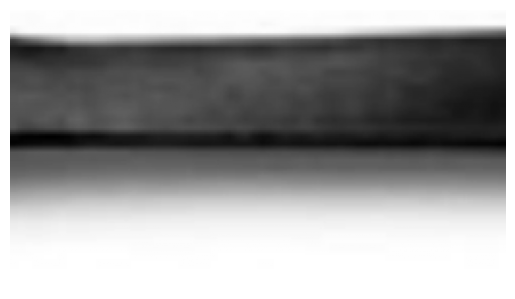

In [3]:
plt.imshow(batch.images[0, 0].to("cpu").numpy(), cmap="gray")
plt.axis("off")
plt.show()

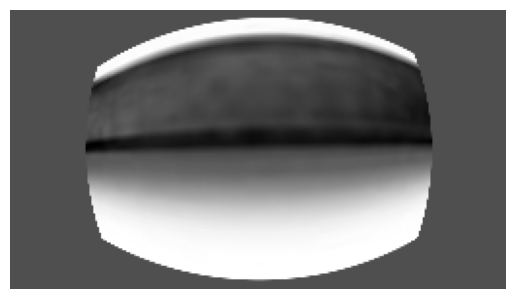

In [4]:
perspective = Perspective(Retina(device=device), Monitor(device=device)).to(device)

out = perspective(batch.images, batch.pupil_center)
img = out[0, 0].detach().to("cpu").numpy()
plt.imshow(img, cmap="gray")
plt.axis("off")
plt.show()

In [5]:
params = perspective.parameters()
for param in params:
    print(param.shape)

torch.Size([12, 2])
torch.Size([12])
torch.Size([12, 12])
torch.Size([12])
torch.Size([3, 12])
torch.Size([3])
torch.Size([3])
torch.Size([3])
torch.Size([])
torch.Size([])
